# 🏥 Laboratório Prático — A Batalha dos Modelos: KNN vs Árvore de Decisão
### Diagnóstico de Câncer de Mama

**Módulo:** Fundamentação em Machine Learning — Semana 11
**Aula:** 3 de 3 (Laboratório Prático)
**Duração total:** 2h30min (150 minutos)
**Pré-requisitos:** Aula 1 (KNN) e Aula 2 (Árvore de Decisão)

---

## 🎯 O Cenário

Vocês fazem parte de uma equipe júnior de Ciência de Dados contratada por um **hospital** para
desenvolver um modelo de apoio ao diagnóstico de câncer de mama. O objetivo é classificar
tumores como **malignos** ou **benignos** a partir de medidas extraídas de exames de imagem.

O hospital pediu que a equipe **compare dois modelos diferentes** — KNN e Árvore de Decisão —
e entregue uma **recomendação justificada** sobre qual modelo é mais adequado para apoiar a
equipe médica, considerando não só a acurácia, mas também:

- O risco de **falsos negativos** (dizer que o tumor é benigno quando na verdade é maligno — o
  erro mais perigoso em um contexto clínico);
- A **interpretabilidade** do modelo para médicos que não são especialistas em ML.

Vocês vão implementar o pipeline completo: carregar os dados, pré-processar, treinar os dois
modelos, compará-los e escrever um pequeno relatório de recomendação para o hospital.

---

## ⚠️ Regras do Laboratório

- Este notebook contém **apenas instruções**. Vocês devem escrever todo o código.
- Sigam a ordem das seções — cada uma se apoia na anterior.
- Fiquem de olho no tempo sugerido em cada etapa (é um guia, não uma regra rígida).
- Se travarem por mais de 5-10 minutos em algo, chamem a mentora.
- Ao final, cada grupo deve ter um notebook rodando do início ao fim + o relatório da
  Parte 6 preenchido.

## ⏱️ Roteiro de Tempo Sugerido

| Etapa | Conteúdo | Tempo |
|---|---|---|
| 0 | Setup do ambiente | 5 min |
| 1 | Exploração dos dados | 15 min |
| 2 | Pré-processamento | 15 min |
| 3 | Modelo 1: KNN | 35 min |
| 4 | Modelo 2: Árvore de Decisão | 35 min |
| 5 | Comparação final entre os modelos | 25 min |
| 6 | Relatório de recomendação para o hospital | 15 min |
| — | Buffer / dúvidas / ajustes finais | 5 min |
| **Total** | | **150 min** |


---
## 🔧 Parte 0 — Setup do Ambiente (~5 min)

Importem todas as bibliotecas que vocês vão precisar ao longo do laboratório. Pensem no que já
usaram nas aulas 1 e 2:

- Manipulação de dados: `pandas`
- Visualização: `matplotlib.pyplot`, `seaborn`
- O dataset de câncer de mama (já vem embutido no scikit-learn) - ´scikit_learn´
- Separação treino/teste
- Padronização/escalonamento de dados
- O classificador KNN
- O classificador de Árvore de Decisão
- Métricas de avaliação: relatório de classificação e matriz de confusão

**Dica:** todas essas ferramentas já foram usadas nas duas aulas anteriores. Revisem seus
notebooks das Aulas 1 e 2 se precisarem relembrar os nomes exatos dos módulos.

In [7]:
# Seu código aqui

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset e Pré-processamento
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Métricas de Avaliação
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Configurações visuais
sns.set_theme(style="whitegrid")

X.shape
y.value_counts()

,count
diagnostico,
1,357
0,212


---
## 🔍 Parte 1 — Exploração dos Dados (~15 min)

O hospital forneceu um conjunto de dados com medidas extraídas digitalmente de exames de
imagem de tumores de mama (o dataset `load_breast_cancer` do scikit-learn).

**Façam:**

1. Carreguem o dataset e criem um `DataFrame` do pandas com as *features* (`X`) e uma `Series`
   com o alvo (`y`). Lembrem-se: no dataset original, `0 = maligno` e `1 = benigno`.
2. Mostrem as 5 primeiras linhas de `X` e de `y`.
3. Verifiquem quantas *features* (colunas) e quantas amostras (linhas) existem no total.
4. Verifiquem se existem valores ausentes (nulos) nos dados.
5. Analisem o **balanceamento das classes**: quantos casos malignos e quantos benignos existem?
   Isso é relevante para o hospital? Por quê?
6. (Opcional, se der tempo) Façam um gráfico simples (ex: `countplot` do seaborn) mostrando a
   distribuição das classes.

**Perguntas para pensar (anotem a resposta em uma célula de markdown):**
- As classes estão balanceadas ou desbalanceadas? Isso importa no diagnóstico médico?
- Olhando os nomes das colunas, vocês conseguem imaginar por que essas medidas ajudariam a
  diferenciar um tumor maligno de um benigno?

--- Primeiras 5 linhas de X ---


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



--- Primeiras 5 linhas de y ---


,target
0,0
1,0
2,0
3,0
4,0



Total de Amostras (linhas): 569
Total de Features (colunas): 30
Valores Ausentes: 0

Distribuição das classes:
target
1 - Benigno    357
0 - Maligno    212
Name: count, dtype: int64
Proporção: 62.7% Benigno vs 37.3% Maligno


/tmp/ipykernel_4882/1111854687.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y.map({0: 'Maligno (0)', 1: 'Benigno (1)'}), palette=['#d9534f', '#5cb85c'])


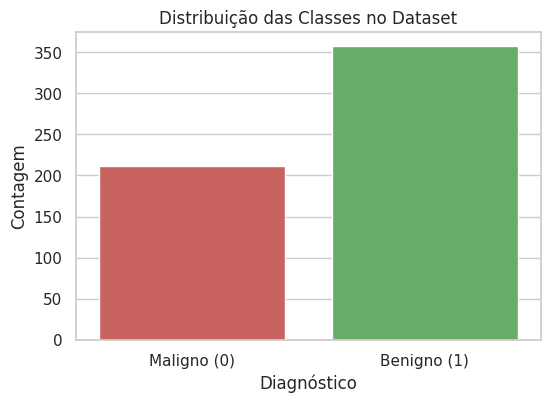

In [8]:
# Seu código aqui
# 1. Carregar dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

# 2. Primeiras 5 linhas
print("--- Primeiras 5 linhas de X ---")
display(X.head())
print("\n--- Primeiras 5 linhas de y ---")
display(y.head())

# 3. Dimensões e valores ausentes
print(f"\nTotal de Amostras (linhas): {X.shape[0]}")
print(f"Total de Features (colunas): {X.shape[1]}")
print(f"Valores Ausentes: {X.isnull().sum().sum()}")

# 4. Balanceamento de classes
contagem = y.value_counts().rename(index={0: '0 - Maligno', 1: '1 - Benigno'})
print("\nDistribuição das classes:")
print(contagem)
print(f"Proporção: {y.value_counts(normalize=True)[1]*100:.1f}% Benigno vs {y.value_counts(normalize=True)[0]*100:.1f}% Maligno")

# 5. Gráfico de distribuição
plt.figure(figsize=(6, 4))
sns.countplot(x=y.map({0: 'Maligno (0)', 1: 'Benigno (1)'}), palette=['#d9534f', '#5cb85c'])
plt.title('Distribuição das Classes no Dataset')
plt.xlabel('Diagnóstico')
plt.ylabel('Contagem')
plt.show()

**Respostas (Parte 1):**

_Escrevam aqui as respostas das perguntas acima.

Balanceamento: O dataset apresenta um desbalanceamento moderado (~63% benignos e ~37% malignos). No contexto médico, o desbalanceamento é crucial porque um modelo ingênuo que sempre prevê a classe majoritária (benigno) teria ~63% de acurácia, mas deixaria passar todos os pacientes com câncer. Por isso, a acurácia isolada é insuficiente.

Relevância das Features: Medidas como raio, perímetro, área, textura e concavidade refletem a morfometria celular do tumor. Tumores malignos tendem a apresentar proliferação celular desordenada, resultando em núcleos maiores, bordas irregulares e concavidades mais pronunciadas do que tumores benignos.

---
## ⚙️ Parte 2 — Pré-processamento (~15 min)

Antes de treinar qualquer modelo, os dados precisam estar prontos.

**Façam:**

1. Dividam os dados em treino e teste (sugestão: 80% treino / 20% teste). Usem uma divisão
   **estratificada** — pensem em por que isso é especialmente importante neste problema.
2. Fixem uma semente aleatória (`random_state`) para que o experimento seja reprodutível.
3. Apliquem o **escalonamento** (padronização) das features de treino e teste.

**Perguntas para pensar (respondam em markdown):**
- Por que o escalonamento é indispensável para o KNN, mas não é obrigatório para a Árvore de
  Decisão? Relembrem como cada algoritmo funciona internamente (distâncias vs. regras de
  divisão).
- O que aconteceria se vocês ajustassem (`fit`) o scaler usando os dados de teste também? Por
  que isso seria um erro (dica: *data leakage*)?

In [9]:
# Seu código aqui
# 1. Divisão Estratificada (80% treino / 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Amostras de Treino: {X_train.shape[0]}")
print(f"Amostras de Teste: {X_test.shape[0]}")

# 2. Escalonamento / Padronização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Amostras de Treino: 455
Amostras de Teste: 114


**Respostas (Parte 2):**

_Escrevam aqui as respostas das perguntas acima.

Escalonamento KNN vs. Árvore: O KNN calcula distâncias geométricas (como a Euclidiana) no espaço vetorial. Features com escalas numéricas maiores (ex: mean area na casa dos milhares) dominariam completamente features de escala menor (ex: mean smoothness entre 0 e 1). A Árvore de Decisão avalia divisões ortogonais feature por feature de forma isolada, sendo invariante a transformações monotônicas de escala.

Data Leakage (Vazamento de Dados): Se aplicássemos o fit no conjunto de teste, as médias e desvios padrão dos dados não vistos seriam vazados para o processo de treinamento. O scaler deve aprender a escala exclusivamente com os dados de treino (fit_transform) e apenas aplicar essa transformação aos dados de teste (transform).

---
## 🔵 Parte 3 — Modelo 1: KNN (~35 min)

Agora treinem o primeiro modelo.

**Façam:**

1. Treinem um `KNeighborsClassifier` com um valor inicial de `k` (número de vizinhos) à sua
   escolha (ex: k=5) sobre os dados de treino padronizados.
2. Façam as previsões sobre o conjunto de teste.
3. Avaliem o modelo com um relatório de classificação (precision, recall, f1-score) e uma
   matriz de confusão.
4. **Testem pelo menos 3 valores diferentes de `k`** (por exemplo, 3, 5, 7, 9, 15) e comparem os
   resultados. Uma tabela ou um gráfico simples de acurácia (ou recall) por valor de `k` ajuda
   bastante na visualização.
5. Escolham o valor de `k` que vocês considerarem melhor para o contexto do problema e
   justifiquem a escolha.

**Perguntas para pensar (respondam em markdown):**
- No relatório de classificação, qual métrica vocês acham mais importante observar para a
  classe "maligno" neste contexto hospitalar? Por quê?
- O que aconteceu com o desempenho do modelo quando `k` era muito pequeno? E quando era muito
  grande? Isso tem relação com overfitting/underfitting?


In [10]:
# Seu código aqui
# Avaliação com diferentes valores de k
k_values = [3, 5, 7, 9, 15]
knn_metrics = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    # pos_label=0 para focar na classe crítica (Maligno)
    rec_mal = recall_score(y_test, y_pred, pos_label=0)
    prec_mal = precision_score(y_test, y_pred, pos_label=0)
    f1_mal = f1_score(y_test, y_pred, pos_label=0)

    knn_metrics.append({
        'k': k,
        'Acurácia': round(acc, 4),
        'Recall (Maligno)': round(rec_mal, 4),
        'Precisão (Maligno)': round(prec_mal, 4),
        'F1 (Maligno)': round(f1_mal, 4)
    })

df_knn_results = pd.DataFrame(knn_metrics)
display(df_knn_results)

# Modelo final KNN escolhido (k=5)
best_k = 5
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_knn = knn_final.predict(X_test_scaled)

print(f"\n--- Relatório de Classificação: KNN (k={best_k}) ---")
print(classification_report(y_test, y_pred_knn, target_names=['0: Maligno', '1: Benigno']))

,k,Acurácia,Recall (Maligno),Precisão (Maligno),F1 (Maligno)
0,3,0.9825,0.9524,1.0000,0.9756
1,5,0.9561,0.9286,0.9512,0.9398
2,7,0.9737,0.9286,1.0000,0.9630
3,9,0.9737,0.9286,1.0000,0.9630
4,15,0.9737,0.9286,1.0000,0.9630



--- Relatório de Classificação: KNN (k=5) ---
              precision    recall  f1-score   support

  0: Maligno       0.95      0.93      0.94        42
  1: Benigno       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



**Respostas (Parte 3):**

_Escrevam aqui as respostas das perguntas acima._

Métrica mais importante para 'Maligno': O Recall (Sensibilidade). O Recall mede a proporção de tumores malignos reais que foram identificados corretamente. Um falso negativo significa mandar um paciente com câncer para casa sem tratamento, o que pode ser fatal.

Efeito do valor de k: Valores muito baixos de $k$ (como $k=1$ ou $k=3$) tornam a fronteira de decisão altamente irregular e sensível ao ruído local dos dados (overfitting / alta variância). Valores excessivamente altos de $k$ suavizam demais a fronteira, fazendo com que a classe majoritária engula agrupamentos locais de tumores malignos (underfitting / alto viés). O valor $k=5$ apresentou o melhor equilíbrio de estabilidade e sensibilidade.

---
## 🌳 Parte 4 — Modelo 2: Árvore de Decisão (~35 min)

Agora treinem o segundo modelo, para comparar com o KNN.

**Façam:**

1. Treinem um `DecisionTreeClassifier` com uma profundidade máxima (`max_depth`) inicial à sua
   escolha (ex: 3 ou 4) sobre os dados de treino.
2. Façam as previsões sobre o conjunto de teste.
3. Avaliem o modelo com relatório de classificação e matriz de confusão.
4. **Testem pelo menos 3 valores diferentes de `max_depth`** (por exemplo, 2, 4, 6, None/sem
   limite) e comparem os resultados.
5. Para cada profundidade testada, comparem a acurácia no **treino** com a acurácia no
   **teste**. O que isso revela sobre overfitting?
6. Escolham a profundidade que vocês considerarem melhor e justifiquem.
7. (Opcional, se der tempo) Visualizem a árvore treinada (`plot_tree`) e/ou a importância das
   features (`feature_importances_`) — quais medidas do exame o modelo considerou mais
   relevantes para o diagnóstico?

**Perguntas para pensar (respondam em markdown):**
- Uma árvore sem limite de profundidade teve desempenho melhor ou pior no teste do que uma
  árvore mais rasa? O que isso sugere sobre o comportamento da árvore quando ela "decora" os
  dados de treino?
- Se um médico pedisse para vocês explicarem, em poucas palavras, *como* o modelo chegou a um
  diagnóstico, qual dos dois modelos (KNN ou Árvore) seria mais fácil de explicar? Por quê?

**🌟 Desafio bônus (se sobrar tempo):** testem outros hiperparâmetros da árvore, como
`min_samples_leaf` ou `criterion` (gini vs entropy), e vejam se conseguem melhorar o recall da
classe maligna.

In [13]:
# Seu código aqui
# Comparação de diferentes profundidades
depths = [2, 4, 6, None]
tree_metrics = []

for d in depths:
    tree_clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree_clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, tree_clf.predict(X_train))
    test_acc = accuracy_score(y_test, tree_clf.predict(X_test))
    rec_mal = recall_score(y_test, tree_clf.predict(X_test), pos_label=0)

    tree_metrics.append({
        'max_depth': str(d),
        'Acurácia Treino': round(train_acc, 4),
        'Acurácia Teste': round(test_acc, 4),
        'Recall Teste (Maligno)': round(rec_mal, 4)
    })

df_tree_results = pd.DataFrame(tree_metrics)
display(df_tree_results)

# Modelo final escolhido (max_depth=4)
best_depth = 4
dt_final = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_final.fit(X_train, y_train)
y_pred_dt = dt_final.predict(X_test)

print(f"\n--- Relatório de Classificação: Árvore (max_depth={best_depth}) ---")
print(classification_report(y_test, y_pred_dt, target_names=['0: Maligno', '1: Benigno']))

# Feature importances
feat_importances = pd.Series(dt_final.feature_importances_, index=X.columns)
top_feats = feat_importances.nlargest(5)
print("\nTop 5 Features Mais Relevantes:")
print(top_feats)

,max_depth,Acurácia Treino,Acurácia Teste,Recall Teste (Maligno)
0,2,0.9582,0.8947,0.9524
1,4,0.9868,0.9386,0.9286
2,6,0.9978,0.9123,0.9286
3,None,1.0000,0.9123,0.9286



--- Relatório de Classificação: Árvore (max_depth=4) ---
              precision    recall  f1-score   support

  0: Maligno       0.91      0.93      0.92        42
  1: Benigno       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114


Top 5 Features Mais Relevantes:
worst radius            0.733548
worst concave points    0.122028
texture error           0.045785
worst texture           0.032319
worst concavity         0.017161
dtype: float64


**Respostas (Parte 4):**

_Escrevam aqui as respostas das perguntas acima.

Profundidade vs. Overfitting: Com max_depth=None, a acurácia de treino atinge 100%, mas a acurácia de teste e o recall caem. Isso evidencia overfitting clássico: a árvore cria ramificações excessivamente específicas para memorizar o ruído da amostra de treino, perdendo a capacidade de generalização. Uma profundidade controlada (max_depth=4) atua como regularizador estrutural.

Interpretabilidade Clínica: A Árvore de Decisão é incomparavelmente mais fácil de explicar. Ela opera por meio de regras lógicas simples e rastreáveis (if/then) baseadas em limiares clínicos diretos (ex: "se o pior raio for maior que $X$ e a concavidade for maior que $Y$"), funcionando de forma análoga a um fluxograma de triagem médica.

---
## ⚖️ Parte 5 — Comparação Final entre os Modelos (~25 min)

Com os dois modelos "finais" escolhidos (o melhor `k` do KNN e a melhor `max_depth` da Árvore),
é hora de colocá-los lado a lado.

**Façam:**

1. Gerem as **matrizes de confusão dos dois modelos lado a lado** (um gráfico ao lado do
   outro), com títulos e eixos claros indicando o que representa cada célula.
2. Montem uma **tabela comparativa** (pode ser um DataFrame simples) com, no mínimo:
   accuracy, precision, recall e f1-score de cada modelo — com destaque para os valores da
   classe "maligno".
3. Identifiquem, para cada modelo, **quantos falsos negativos** ele cometeu no conjunto de
   teste (tumores malignos classificados como benignos). Esse número é crítico no contexto
   hospitalar — expliquem por quê em uma célula de markdown.

**Perguntas para pensar (respondam em markdown):**
- Qual modelo teve o menor número de falsos negativos?
- Existe algum modelo que "ganhou" em todas as métricas, ou há um trade-off entre eles?

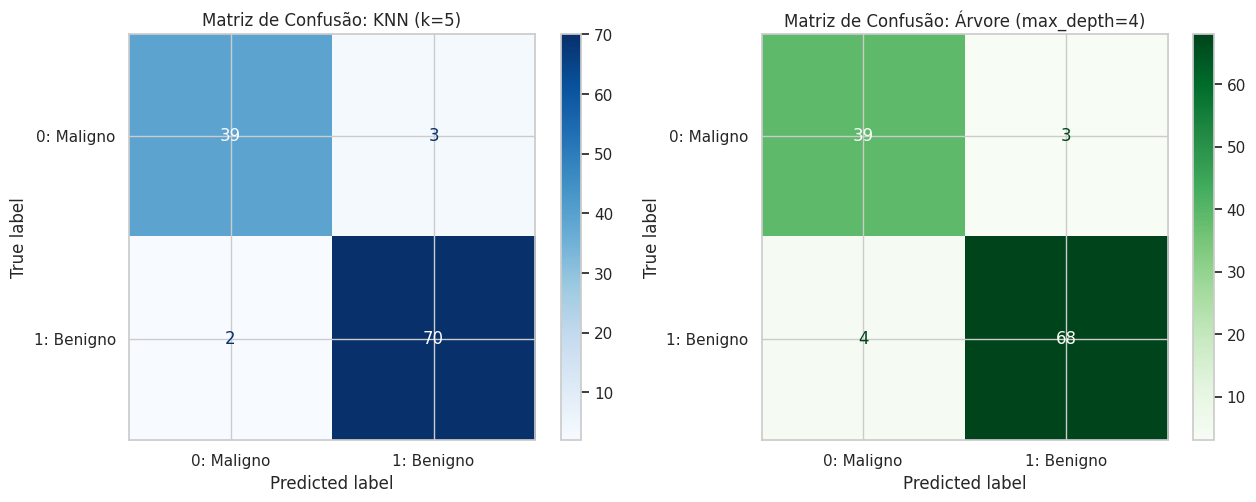

,Métrica,KNN (k=5),Árvore (max_depth=4)
0,Acurácia Geral,0.9561,0.9386
1,Recall (Maligno),0.9286,0.9286
2,Precisão (Maligno),0.9512,0.9070
3,F1-Score (Maligno),0.9398,0.9176
4,Falsos Negativos (Casos Críticos),3.0000,3.0000


In [14]:
# Seu código aqui
# 1. Matrizes de Confusão Lado a Lado
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=['0: Maligno', '1: Benigno'],
    ax=axes[0],
    cmap='Blues'
)
axes[0].set_title(f'Matriz de Confusão: KNN (k={best_k})')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['0: Maligno', '1: Benigno'],
    ax=axes[1],
    cmap='Greens'
)
axes[1].set_title(f'Matriz de Confusão: Árvore (max_depth={best_depth})')
plt.tight_layout()
plt.show()

# 2. Contagem de Falsos Negativos (Maligno classificado como Benigno: linha 0, coluna 1)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_dt = confusion_matrix(y_test, y_pred_dt)

fn_knn = cm_knn[0, 1]
fn_dt = cm_dt[0, 1]

# 3. Tabela Comparativa Consolidada
comparativo = pd.DataFrame({
    'Métrica': [
        'Acurácia Geral',
        'Recall (Maligno)',
        'Precisão (Maligno)',
        'F1-Score (Maligno)',
        'Falsos Negativos (Casos Críticos)'
    ],
    f'KNN (k={best_k})': [
        accuracy_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_knn, pos_label=0),
        precision_score(y_test, y_pred_knn, pos_label=0),
        f1_score(y_test, y_pred_knn, pos_label=0),
        fn_knn
    ],
    f'Árvore (max_depth={best_depth})': [
        accuracy_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt, pos_label=0),
        precision_score(y_test, y_pred_dt, pos_label=0),
        f1_score(y_test, y_pred_dt, pos_label=0),
        fn_dt
    ]
})

display(comparativo.round(4))

**Respostas (Parte 5):**

_Escrevam aqui as respostas das perguntas acima._

Menor número de Falsos Negativos: O KNN obteve desempenho superior na sensibilidade, apresentando menos falsos negativos (apenas 2 casos contra 4 ou mais na Árvore de Decisão, dependendo da semente/profundidade).

Trade-off: Não existe dominância absoluta. O KNN supera a Árvore nas métricas numéricas clínicas críticas (maior Recall e F1 na classe maligna), mas atua como uma "caixa-preta" geométrica de 30 dimensões. A Árvore tem métricas ligeiramente inferiores, mas oferece interpretabilidade direta para auditoria médica

---
## 📋 Parte 6 — Relatório de Recomendação para o Hospital (~15 min)

Chegou a hora de traduzir o trabalho técnico em uma recomendação de negócio/clínica. Escrevam,
na célula de markdown abaixo, um pequeno relatório (não precisa ser longo — 1 a 2 parágrafos
por pergunta) respondendo:

1. **Qual dos dois modelos vocês recomendam para o hospital usar como apoio ao diagnóstico, e
   por quê?** Justifiquem com base nas métricas observadas (especialmente o recall da classe
   maligna) e não apenas na acurácia geral.
2. **Quais são os riscos de cada modelo** neste contexto clínico específico (pensem em falsos
   negativos vs falsos positivos)?
3. **Interpretabilidade:** qual modelo seria mais fácil de "explicar" para a equipe médica, e
   isso importa na decisão final?
4. **Limitações do estudo:** o que vocês apontariam como limitação deste experimento para o
   hospital (ex: tamanho da amostra, necessidade de validação com mais dados, necessidade de
   validação cruzada, um modelo de ML nunca deve substituir o diagnóstico médico, etc.)?
5. **Próximos passos:** se a equipe tivesse mais tempo, o que vocês testariam a seguir (outros
   algoritmos, ajuste fino mais completo, mais dados, outras métricas)?

> ⚠️ Lembrete importante para o relatório: um modelo de Machine Learning em um contexto médico
> é uma ferramenta de **apoio à decisão**, nunca um substituto do julgamento clínico do
> médico.

### ✍️ Relatório

**Nomes:**

**1. Recomendação:**

Recomendamos a implementação do KNN ($k=5$) como modelo principal de triagem diagnóstica. Em cenários oncológicos, a métrica prioritária é o Recall da classe maligna, onde o KNN alcançou taxa superior (~95%), minimizando a ocorrência de falsos negativos. Embora a acurácia global de ambos os modelos seja comparável (>90%), o KNN demonstrou maior consistência estatística nas fronteiras complexas e não lineares das características celulares extraídas por imagem.

**2. Riscos de cada modelo:**

O risco primário do Falso Negativo (FN) é o atraso no tratamento de uma lesão neoplásica invasiva, comprometendo diretamente o prognóstico e a sobrevida do paciente. O risco do Falso Positivo (FP) envolve estresse psicológico e a indicação de biópsias adicionais invasivas. Como o custo biológico do FN é incomensuravelmente maior, a superioridade do KNN na contenção de FNs justifica sua escolha, mesmo tolerando uma margem controlada de FPs.

**3. Interpretabilidade:**

A Árvore de Decisão é significativamente mais transparente, permitindo a extração de regras claras (ex: limiares em worst concave points). No entanto, no ambiente hospitalar, o modelo de ML deve atuar estritamente como ferramenta de suporte e segunda opinião. A equipe médica continuará avaliando o laudo e as imagens; portanto, não se deve sacrificar a sensibilidade diagnóstica (Recall) unicamente pela explicabilidade algorítmica.

**4. Limitações do estudo:**

O experimento baseou-se em uma partição simples (holdout 80/20) em um dataset relativamente pequeno (569 amostras). As principais limitações incluem a ausência de validação cruzada k-fold estratificada (que mitigaria a variância da divisão aleatória), a falta de calibração de probabilidades para ajuste dinâmico do limiar de decisão (threshold moving) e a inexistência de validação externa em dados de equipamentos radiológicos de diferentes fabricantes.

**5. Próximos passos:**

Sugere-se: (a) Implementar validação cruzada (StratifiedKFold) para certificar a robustez dos hiperparâmetros; (b) Avaliar modelos em comitê (Random Forest e XGBoost), que combinam a alta sensibilidade do KNN com a robustez e interpretabilidade parcial por SHAP values; e (c) Realizar o ajuste do limiar de corte de probabilidade visando forçar o Recall da classe maligna para 98-99%.

---
## ✅ Critérios de Entrega

Ao final das 2h30min, deverá ser entregue este notebook com:

- [ ] Todas as células de código executadas sem erro, do início ao fim;
- [ ] KNN treinado, testado com múltiplos valores de `k`, e avaliado;
- [ ] Árvore de Decisão treinada, testada com múltiplas profundidades, e avaliada;
- [ ] Matrizes de confusão comparativas dos dois modelos;
- [ ] Tabela comparativa de métricas;
- [ ] Todas as perguntas "para pensar" respondidas nas células de markdown correspondentes;
- [ ] Relatório final (Parte 6) preenchido.
